# **Integrating Machine Learning into Chemistry Education: Classifying IR Spectra of Disubstituted Aromatics as an Introductory ML Exercise**


# Module 1: Understanding how to work with a dataset for a KNN machine learning model

## 1. Introduction

Objectives:


1.   Learn what is machine learning

1.   Know how to manipulate a data set by using libraries such as pandas and numpy
2.   Understand the leanrning process of a machine learning model and how does it read a data set.

**What is machine learning?**

Machine learning (ML) is a branch of artificial intelligence in which algorithms identify patterns and generate predictions from data. ML provides a rich context for developing skills such as problem decomposition, coding fluency, and model evaluation. Engaging students in the process of training an ML model therefore offers an authentic opportunity to foster computational thinking and data interpretation while simultaneously strengthening technological literacy.

There a many types of models also know as mathematical argorightm rangign from the most basic and easy to vizualize and undertand the math behing to more complex and high dimension models.

In this series of module we will focus on the most basic multiclass algorith to learn, K-nearest neighbor. We will learn how it works, how to use it and how to optimize it to achive the best results in classifying a series of orto, meta, para compound IR spectra.

**What does a model need to succeed?**


**A data set**

 * Every machine learning model requires a suitable dataset to perform predictions or classifications. This research is no exception; it draws upon the work of Cahill et al., *Assignment of Regioisomers Using Infrared Spectroscopy: A Python Coding Exercise in Data Processing and Machine Learning*, which provides a dataset comprising a total of 380 spectra. These spectra were obtained using a Shimadzu IRSpirit Fourier-transform infrared (FTIR) spectrophotometer equipped with a QATR-S attenuated total reflectance (ATR) accessory. Each spectrum represented an average of 10 scans, collected within the 400–4000 cm⁻¹ range at a resolution of 0.9 cm⁻¹. For each compound analyzed via infrared spectroscopy, five independent measurements were performed using five samples of the same compound; consequently, the dataset contains five spectra for each compound. In total, the dataset consists of 76 disubstituted benzene compounds—21 *ortho*, 22 *meta*, and 33 *para*—with five spectral replicates for each.

In order that our model succed we will implement such data set. This data set is located in the _____________, named IR Spectra Data. In here you will find spectra in .txt format.


## 2. Data Exploration with Pandas


In order that our model succed we will implement such data set. This data set is located in the _____________, named IR Spectra Data. In here you will find spectra in .txt format.

To explore and manipulate the data, we will use the Pandas library. Pandas is a Python library that allows us to work with data in table format. Its main structure is called a DataFrame, which works similarly to an Excel table because it contains rows and columns.

In this module, Pandas will be used to:

1. Load the data from a CSV file.
2. View the first rows of the dataset.
3. Identify the available columns.
4. Check the size of the dataset.

6. Select the variables that will be used in the model.
7. Prepare the data before training the KNN model.


We will start by importing the library wich is is allready install in google collab. We can use the function 'as' to name the library to a shorter name.




```
import pandas as pd
```




## 3. Loading the Data


Due to the complexity of having a total of 380 spectras we will first load and preprcess one spectra of the folder _____. And then we will apply the same process to all spectra.

To load a CSV file in Google Colab, we use the following function:



```
DataFrame = pd.read_csv('file_directory.csv')
```

We can get the file directory by just right cliking one of the .csv spectra file and copying its path into the function.

Example:


```
df = pd.read_csv('path')
```

Now its your turn, try to import pandas and load a csv file from the folder. Try to see what the code tells you when you run it!

Use the function DataFrame_Name.head() to see the first 5 rows of the table.

In [ ]:
#Code here!
#--------------------------------





#--------------------------------

## 4. Loading the Infrared Spectrum Data Correctly

After looking at the raw infrared spectrum data, we can see that the file is not organized like a normal table. The file contains extra text at the beginning, such as the title, data type, and units. It also contains the actual numerical data for the spectrum.

What you are seeing is the raw data of an infrared spectrum. An infrared spectrum is basically a two-dimensional graph made up of x and y coordinates. In this case, the x-axis represents the wavenumber, usually measured in cm⁻¹, and the y-axis represents percent transmittance, written as %T. At first, the raw data may look confusing because both values appear together in the same row. However, the first value in each row corresponds to the wavenumber, and the second value corresponds to the percent transmittance.


To load this .csv file correctly, we use the following code:



```
df = pd.read_csv( 'path',  index_col='Wavenumber/cm-1',names=["Wavenumber/cm-1","% Transmittance"],skiprows=4,delimiter=r"\s+")
```

As you can see we now used 2 new parameter for the read_csv function. Lets see what this new parameters are use for:


* index_col='Wavenumber/cm-1' : Sets the Wavenumber/cm-1 column as the DataFrame index. This allows the wavenumber values to act as row labels instead of a regular data column.

* names=["Wavenumber/cm-1", "% Transmittance"] : Assigns names to the columns when the file does not contain a header row or when you want to replace the existing column names.

* skiprows=4 : Skips the first 4 rows of the file. These rows contain metadata (such as the title and units) rather than the numerical spectrum data.

* delimiter=r"\s+" : Tells Pandas that the values are separated by one or more whitespace characters (spaces or tabs). This allows Pandas to correctly split each line into separate columns.


It is important to understand that every dataset you encounter may be formatted differently. Some files use commas to separate values, while others use spaces, tabs, or other delimiters. Some datasets may also contain metadata that you want to skip before reading the actual data.

Because every dataset is unique, it is important to first understand its structure and then check the documentation to find the appropriate parameters for loading it correctly. The official Pandas documentation is an excellent resource if you have additional questions or need to explore more options.

https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html

Now try to load your dataframe correctly! Remember to use the .head function to always see the first rows of your dataframe.

In [ ]:
#Code here!
#--------------------------------





#--------------------------------

,% Transmittance
Wavenumber/cm-1,
399.826377,79.121053
400.183684,79.790171
400.540991,78.295038
400.898298,79.127124
401.255605,76.528241


**Now if you got it all right you are suppose to get something like this: **



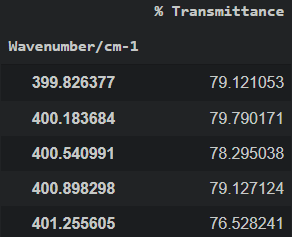

## 5. Vizualizing a Dataset with matplotlib

Some times having just a table of data, isnt enough to say for sure that we loaded correctly the data correctly. Thats why its is important to have a way to vizualize this data and be for sure it loaded corrctly.

There are many python libraries dedicated to the vizualitation of data. Just as said in this module we will be covering the basics of vizualizing data using Matplotlib. Matplotlib is a Python library used to create graphs and data visualizations. It provides a simple interface for generating a wide variety of plots, such as line graphs, bar charts, scatter plots, histograms, and many others. Since it is built on top of NumPy, it works efficiently with numerical data and is widely used in data analysis and machine learning.


In order to vizualize the dataframe we first need to import the library we  first need to import the pyplot module.


```
import matplotlib.pyplot as plt
```

The alias plt is simply a shorter name for matplotlib.pyplot. Using this alias is the standard convention in Python, making plotting commands shorter and easier to read.


To create a graph, we need to understand how our DataFrame is organized. A Pandas DataFrame consists of one or more Series, where each Series represents a column of data. Matplotlib can use these Series as the x- and y-coordinates of a graph.

In our datframe we can atribute the x- coordinates to the index/wavenumber column of our dataframe, just like a any other infrared spectra. And then we can get the transmitance column for the y- axis.

Example:

```
#To create a 2d plot we use the following function
plt.plot(df['x- coordinates'] , df['y- coordinates'])

#In other to see the plot we use...
plt.show()
```
Now your turn!

Try to create a plot where the x- coordinates are the column name 'Wavenumber/cm-1' and the y- coordinates '% Transmittance'. Remeber when calling a series of a pandas dataframe we use ['column name']. When we want to use the index of a pandas dataframe, instead of using ['column name'] we use the atribute .index.


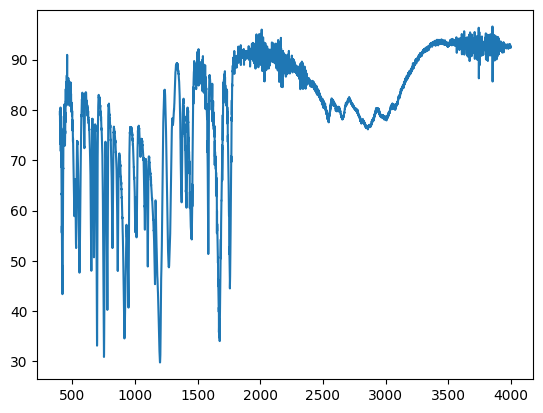

In [ ]:
#Code here!
#--------------------------------







#--------------------------------

So far so good, if the code is correctly written we are suppose to see a graph of one of the infrared spectra dataframe used before.

There are other things one can add and change to the graph such as title, axis names, colors, grid, style, size, etc. For this module, we will remain simple in terms of ploting. However here is an example of a graph could look like.



```
import matplotlib.pyplot as plt
df = pd.read_csv( 'path',names=["Wavenumber/cm-1","% Transmittance"],skiprows=4,delimiter=r"\s+")
plt.style.use('ggplot')
plt.plot(df.index , df['% Transmittance'], c = 'green')
plt.title('Acetoxybenzoic Spectra')
plt.xlabel('Wavenumber/cm-1')
plt.ylabel('% Transmittance')
plt.grid(True)
plt.show()
```



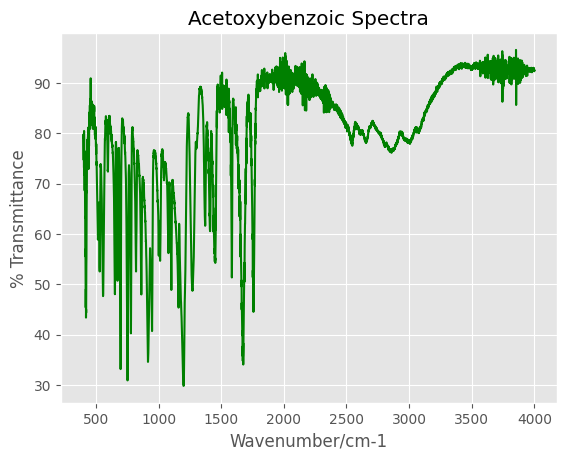


If you are interested on learning more in depht in ploting and data vizualization in matplotlib you can always check the documentation.
https://matplotlib.org/stable/index.html

# Module 2: Data Preprocesing



## 1. Introduction

As we already know, the data we give to our machine learning model is the most crucial step. This is the step that all of our fidings and results will depend on. A machine learning model in general identifies the most subtle diferences between spectras or samples. However, if this subtle changes are cause by external factors, then there would unwanted classifications or predictions from the model. Data presposeising comes into play here. The models dont ignore any differences for each sample we give it. This means every differrence that we give to the model have to be genuine. In our case, our model have to indetigy and clasify diferences in transmitance intensity for each sample we give it. Any other differences are irrelevant and must be eliminated to avoid confusion and incorrect clasifications. In fact the model could use those external cause difference as an important factor to generalize and understand every spectra.


### **But what external factor affect infrared spectra, and how could we eliminate them?**



First we need to understand and identifyevery external factor that affect the messurement of a infrared spectra. One of this factor is the precision of the instrument use for the infrared spectra. As we could see the wavenumbers in the spectra that we loaded had a a los of decimal places. This is due to thhe high precision that the infrared spectra instrument used. This could present several difficulties due to possible inconsistencies in the exact wavenumbers across all spectral files, the difficulty of selecting a specific wavenumber because of the large number of values present, or even the incompatibility of adding new spectra from other instruments to expand the dataset due to subtle differences in the recorded wavenumbers.

Another factor that we can identify can be seen if we load two spectras of the same compund, just as the figure below. We can see that even though they are the same compound, their spectra do not align perfectly. The red spectrum appears to be slightly lower than the blue one. This difference is likely due to variations in the amount of the compound measured. Meaning that their transmitace arent exactly equal.

the amount of the sample that was messure. If we were to messure the same compund in different quantities we would get the same relative transmitance intensity, however its base lines would be slightly different as show in the figure.






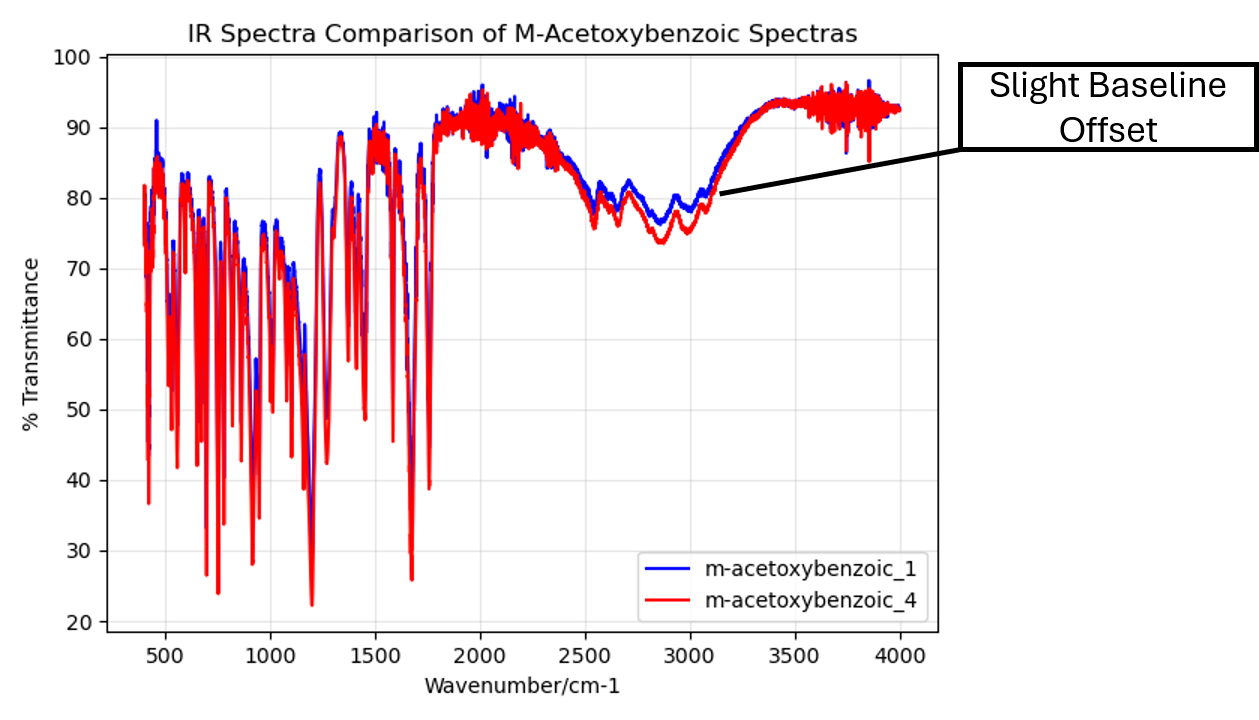

In [ ]:
import pandas as pd


df1 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data - Raw IR Spectra/m-acetoxybenzoic_1.txt',index_col='Wavenumber/cm-1',names=["Wavenumber/cm-1","% Transmittance"],skiprows=4,delimiter=r"\s+")
df2 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data - Raw IR Spectra/p-xylylenediamine_4.txt',index_col='Wavenumber/cm-1',names=["Wavenumber/cm-1","% Transmittance"],skiprows=4,delimiter=r"\s+")
print(df2,df1)




                 % Transmittance
Wavenumber/cm-1                 
399.826377             44.578769
400.183684             44.108513
400.540991             40.844820
400.898298             39.666766
401.255605             42.684250
...                          ...
3998.621081            92.658652
3998.978388            92.629197
3999.335695            92.486361
3999.693002            92.476261
4000.050309            92.608617

[10077 rows x 1 columns]                  % Transmittance
Wavenumber/cm-1                 
399.826377             79.121053
400.183684             79.790171
400.540991             78.295038
400.898298             79.127124
401.255605             76.528241
...                          ...
3998.621081            92.641848
3998.978388            92.458833
3999.335695            92.338130
3999.693002            92.421550
4000.050309            92.467210

[10077 rows x 1 columns]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Interpolation

## 3. Normalization

## 4. Data Truncation

Now that we identify on of those external factor we will now proceed to eliminate it. For this we will need pandas.



```
import pandas as pd
```



#Module 3: Knn model training and evaluation

## Construyendo el modelo

Para contruir modelos de ML se utiliza la libreria scikit-learn.

Existen 4 pasos para contruir un modelo de ML en sci-kit learn son:

1.   Definir el tipo de modelo a construir. Un ejemplo de esto es el modelo decision tree.

2.  Identificar y capturar patrones de la data proveida. Este es el corazon del modelo. (Fit the model)


3. Predecir el dato o variable que queramos predecir utilizando el modelo.

4. Determinar/Evaluar cuan effectivo y certero son las predicciones del modelo.(Model Validation)

## Validacion del modelo

- Generalmente al construir un modelo queremos evaluar cuan valido son sus predicciones.

- Esta validacion se basa en la pregunta de cuan cercano o exactos son las predicciones al valor real.

- El primer paso para validar nuestro modelo es resumir la calidad del modelo en una forma facil de entender. Ya que si evaluamos 10,000 predicciones pueden malos como bueno resultados, mirando 1 a 1 cada uno de estos no seria eficiente. Una forma mas efectiva de evaluar esto es utilizando una metrica.


Existen muchas metricas para resumir la calidad del modelo. **Uno de estas metricas es el error absoluto medio(MAE)**
- MAE: error = |Vreal - Vpredecido|

Se obtiene el valor absolut del error de cada prediccion y se calcula el promedio de esos valores y errores. Esto medira la calidad del modelo.

En este calculo se dira: En promedio, nuestras predicciones se desvían aproximadamente en X.



## Problema de resultados "In-Sample"

No es practico validar nuestro modelo con data utilizada features para entrenar nuestro modelo. Ya que queremos ver su validez en predecir nueva data.

Debido a esto es recomendable dividir todo la data utilizada en el modelo en dos categorias:

1. Feature Data: Data utilizada para entrenar el modelo. (Fit the model)

2. Validation data: Data utilizada para validar el modelo.(MAE)


Podemos aplicar este concepto utilizando una funcion llamada train_test_split para separar la data en estas dos categorias.

Donde generamos 4 varables 2 variables sera el precio y los features a utilizar como data para entrenar el modelo. Y 2 variables seran los features y el precio utilizado para evaluar las predicciones del modelo.

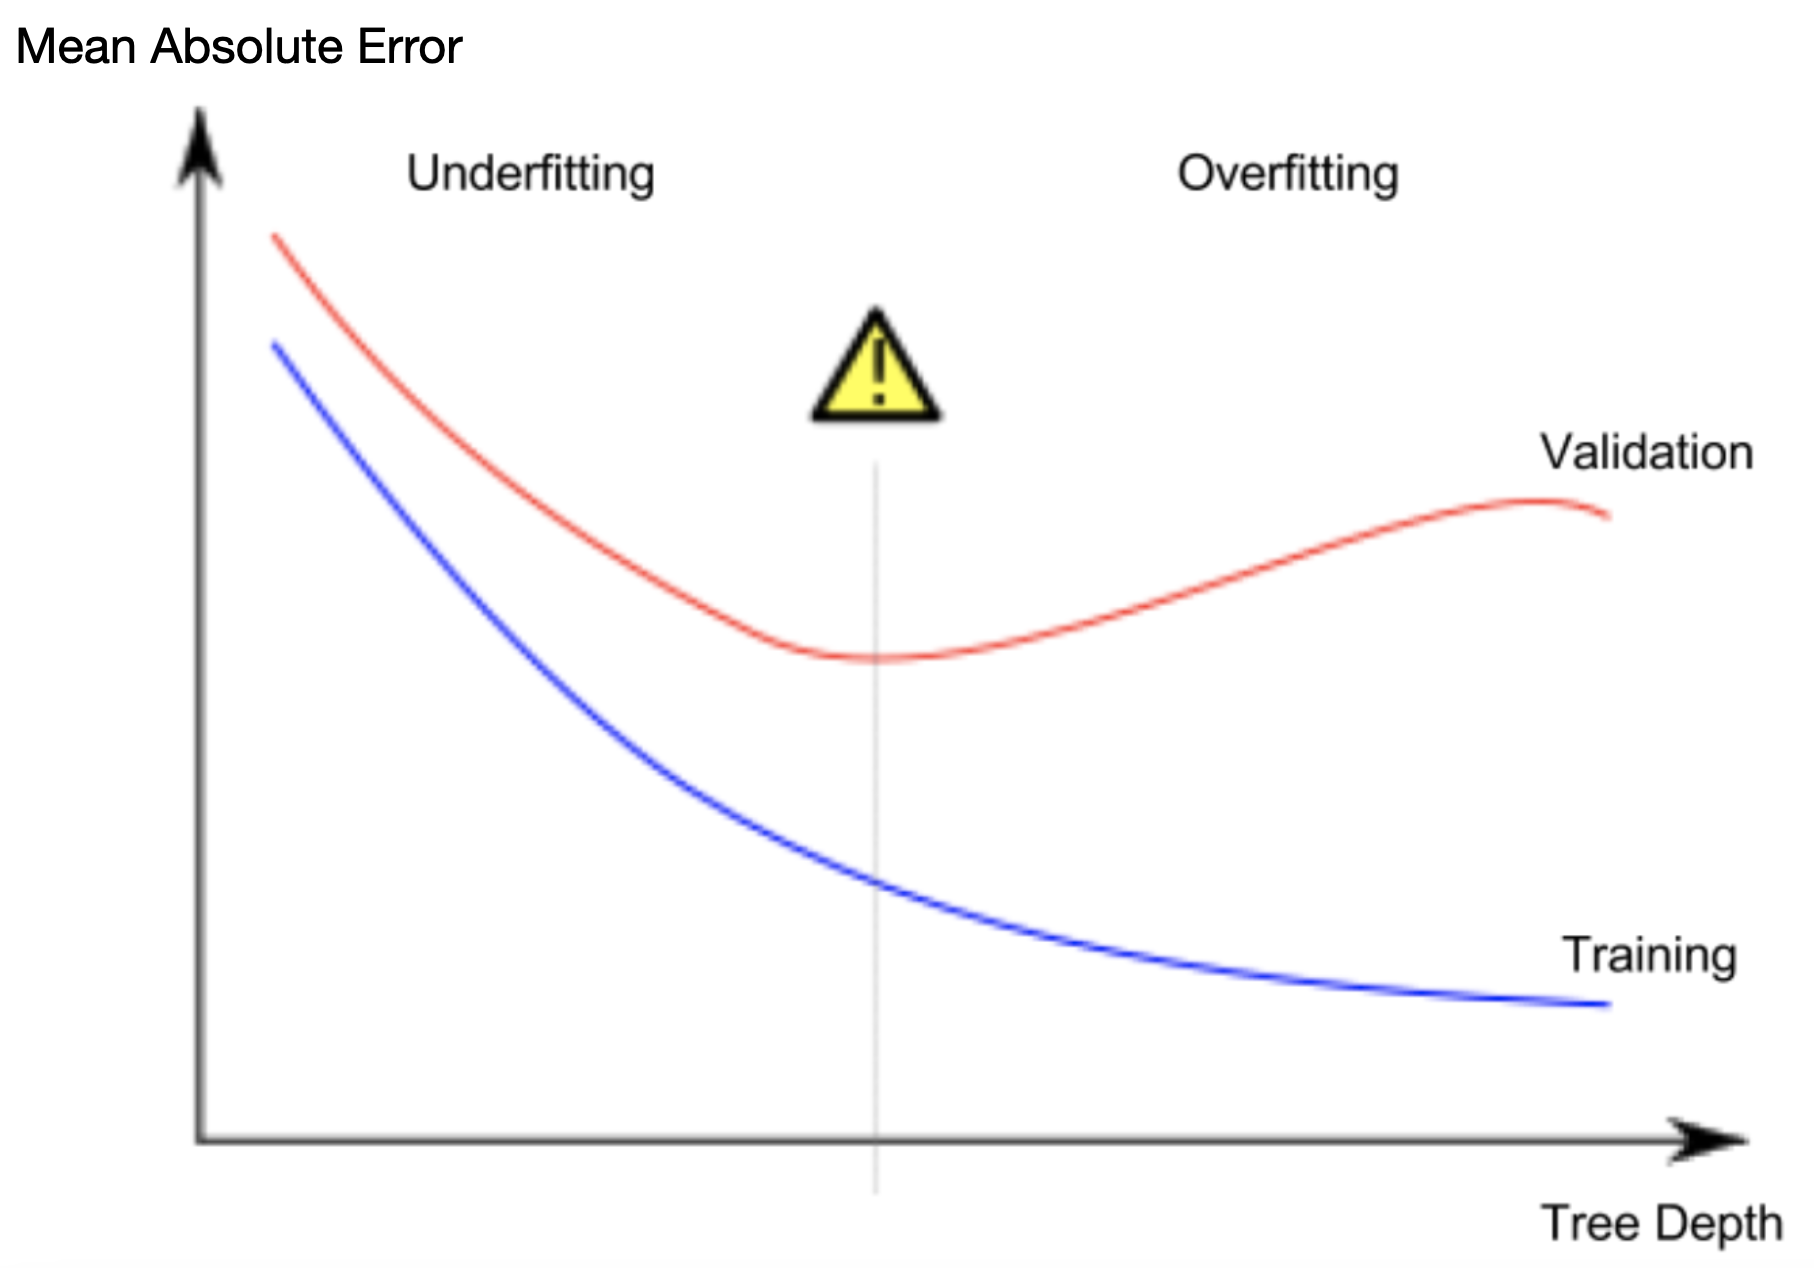

# Module 4: Evaluation metrics